# Analyze Permitivity Data

- **device_id** is quantified id of the sensor and **device_name** is the id on the sticker of the sensor:
    - in dictoinairy device_name_ids you can find all device_ids (e.g. 396) linked to the sensor_ids (e.g. firefly2_0173)
- **located** is the location of the sensor in Leiden:
    - in df_sensor_info you can find all sensor_ids (e.g. firefly2_0173) linked to a location with together with a **date_located**

### Get Parameters

In [1]:
from default_parameters import get_parameters

token, device_name_ids = get_parameters()

### Get Data

In [2]:
import pandas as pd
from datetime import datetime

sensor_cols = ['located','device_name','located_datum','located_einddatum']
new_col_names = ['timestamp', 'device_name', 'located', 'omschrijving', 'foto_1','foto_2', 'located_diepte',
                          'lat_lon','located_datum_old','located_datum','located_tijd','located_einddatum','foto_3', 'foto_4', 
                          'leeftijd_plant', 'soort_plant','located_regio', 'extra_omschrijving']

df_sensor_id_name = pd.DataFrame.from_dict(device_name_ids, orient='index', columns=['device_id']).reset_index().set_index('device_id')
df_sensor_id_name.columns=['device_name']

df_sensor_info_org = pd.read_excel('./data/Water in the cloud (Responses).xlsx')

df_sensor_info = df_sensor_info_org.copy()
df_sensor_info.columns = new_col_names
df_sensor_info = df_sensor_info[sensor_cols]
df_sensor_info['device_name'] = 'firefly2_' + df_sensor_info['device_name'].str[-4:]
df_sensor_info = df_sensor_info.merge(df_sensor_id_name.reset_index(),how='left')
df_sensor_info = df_sensor_info[sensor_cols[:2] + ['device_id'] + sensor_cols[2:]]

large_date = pd.to_datetime(pd.Timestamp.max.date())
df_sensor_info['located_einddatum'] = df_sensor_info['located_einddatum'].fillna(large_date)

df_org = pd.read_excel('./data/Permittivity_updated.xlsx')
df_org.drop_duplicates(inplace=True)
df_org.columns = ['timestamp', 'gateway_receive_time', 'device_id', 'value', 'date', 'time',
       'year', 'month', 'day', 'hour', 'minute', 'second']

df_sensor_info

,located,device_name,device_id,located_datum,located_einddatum
0,Arendshorst,firefly2_0193,418,2023-07-04,2262-04-11
1,Veluwemeerlaan,firefly2_0137,362,2023-07-04,2262-04-11
2,Moskee Zwijgerlaan (old),firefly2_0183,408,2023-06-06,2023-07-01
3,Langegracht Politie,firefly2_0191,416,2023-07-04,2262-04-11
4,Molen Lammermarkt,firefly2_0144,369,2023-07-04,2262-04-11
5,Haven binnenstad,firefly2_0135,360,2023-07-04,2262-04-11
6,Beuk vismarkt,firefly2_0180,405,2023-07-04,2262-04-11
7,Nieuweroord,firefly2_0179,404,2023-07-04,2262-04-11
8,Geesgrond West,firefly2_0174,397,2023-07-04,2262-04-11
9,Ketelmeer rotonde (2),firefly2_0173,396,2023-07-04,2262-04-11


# Summarize sensordata

In [3]:
# df_summary = pd.DataFrame(df.groupby('device')['gateway_receive_time'].max())
df_summary = df_org.groupby('device_id').agg(
    max_gateway_receive_time=('gateway_receive_time', 'max'),
    count_datapoints=('gateway_receive_time', 'count'),
    mean_permittivity=('value', 'mean'))
df_summary = df_summary.join(df_sensor_id_name)
df_summary.sort_values('max_gateway_receive_time')

active_sensors_info = df_summary.reset_index().merge(df_sensor_info)
active_sensors_info = active_sensors_info.merge(df_org[['gateway_receive_time','device_id','value']],how='left',left_on=['max_gateway_receive_time','device_id'], right_on = ['gateway_receive_time','device_id']) \
                                         .drop(columns=['gateway_receive_time'])
active_sensors_info = active_sensors_info[['located', 'device_name', 'device_id', 'located_datum', 'value', 
                               'max_gateway_receive_time', 'count_datapoints','mean_permittivity']]
active_sensors_info.to_excel('./data/permittivity_overview.xlsx', index=False)

active_sensors_info

,located,device_name,device_id,located_datum,value,max_gateway_receive_time,count_datapoints,mean_permittivity
0,Beethovenpark,firefly2_0027,54,2023-07-04,9.33,2023-07-19 11:38:16,2887,11.033159
1,Ijselmeerlaan berm (old),firefly2_0027,54,2022-01-28,9.33,2023-07-19 11:38:16,2887,11.033159
2,Vijf meilaan (2),firefly2_0004,93,2023-07-04,20.83,2023-07-19 11:18:43,927,9.813797
3,Burggravenlaan (old),firefly2_0004,93,2022-01-28,20.83,2023-07-19 11:18:43,927,9.813797
4,Vijf meilaan (1),firefly2_0102,208,2023-07-04,16.04,2023-07-19 11:44:15,1718,9.023254
5,Ijselmeerlaan rotonde (old),firefly2_0102,208,2022-02-02,16.04,2023-07-19 11:44:15,1718,9.023254
6,Boshuizerkade,firefly2_0131,356,2023-07-04,5.68,2023-07-19 08:49:43,241,3.395975
7,Haven binnenstad,firefly2_0135,360,2023-07-04,10.40,2023-07-19 11:52:29,249,10.967831
8,Tasmanpark (old),firefly2_0136,361,2023-05-23,5.54,2023-07-19 09:32:35,247,7.555992
9,Veluwemeerlaan,firefly2_0137,362,2023-07-04,7.35,2023-07-19 11:24:03,205,6.607902


### Filter data located_datetime > gateway_receive_time

In [4]:
df = df_sensor_info.merge(df_org)
df = df[(df['gateway_receive_time'] > df['located_datum']) & (df['gateway_receive_time'] < df['located_einddatum'])]
# df[df['device_id'] == 418].sort_values(by=['gateway_receive_time'], ascending=False)
df

,located,device_name,device_id,located_datum,located_einddatum,timestamp,gateway_receive_time,value,date,time,year,month,day,hour,minute,second
157,Arendshorst,firefly2_0193,418,2023-07-04,2262-04-11,1688449132,2023-07-04 07:38:52,9.09,2023-07-04,07:38:52,2023,7,4,7,38,52
158,Arendshorst,firefly2_0193,418,2023-07-04,2262-04-11,1688434887,2023-07-04 03:41:27,9.06,2023-07-04,03:41:27,2023,7,4,3,41,27
162,Arendshorst,firefly2_0193,418,2023-07-04,2262-04-11,1688620081,2023-07-06 07:08:01,16.26,2023-07-06,07:08:01,2023,7,6,7,8,1
163,Arendshorst,firefly2_0193,418,2023-07-04,2262-04-11,1688577365,2023-07-05 19:16:05,16.96,2023-07-05,19:16:05,2023,7,5,19,16,5
164,Arendshorst,firefly2_0193,418,2023-07-04,2262-04-11,1688563119,2023-07-05 15:18:39,17.39,2023-07-05,15:18:39,2023,7,5,15,18,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15863,Joram thuis,firefly2_0190,415,2023-06-19,2262-04-11,1689683889,2023-07-18 14:38:09,9.56,2023-07-18,14:38:09,2023,7,18,14,38,9
15864,Joram thuis,firefly2_0190,415,2023-06-19,2262-04-11,1689669685,2023-07-18 10:41:25,9.54,2023-07-18,10:41:25,2023,7,18,10,41,25
15865,Joram thuis,firefly2_0190,415,2023-06-19,2262-04-11,1689655489,2023-07-18 06:44:49,9.54,2023-07-18,06:44:49,2023,7,18,6,44,49
15866,Joram thuis,firefly2_0190,415,2023-06-19,2262-04-11,1689641293,2023-07-18 02:48:13,9.59,2023-07-18,02:48:13,2023,7,18,2,48,13


### Time Series Heatmap

In [5]:
# timeseries_heatmap(dataframe=df, max_entities=len(df['device_id'].unique()), entity_column='located', sortby='date')

### Time Series Pandas Profile

In [6]:
# for device_id in df['device_id'].unique():
#     profile = ProfileReport(df[df['device_id'] == device_id], tsmode=True, sortby="gateway_receive_time")
#     profile.to_file(f'C:\\Users\\JSpan\\OneDrive - ilionx Group BV\\03 Projects\\17 - Gemeente Leiden - water\waterleiden\profile_reports\\{device_id}_profile_report.html')

# profile.to_notebook_iframe()

In [7]:
# TODO:
# per device bepalen:
# - voor de pandas ts profiling uit
# - wat de sensorvalue interval is
# - wat is min/max gatewaytijd
# - voeg locaties toe aan sensor_id
# - plot time series
# - battery voltage vanuit API toevoegen
# - 

In [8]:
import pandas as pd
import numpy as np

# Define the conditions and corresponding values
conditions = [
    (df['gateway_receive_time'].dt.time >= pd.to_datetime('00:00:00').time()) & (df['gateway_receive_time'].dt.time < pd.to_datetime('06:00:00').time()),
    (df['gateway_receive_time'].dt.time >= pd.to_datetime('06:00:00').time()) & (df['gateway_receive_time'].dt.time < pd.to_datetime('12:00:00').time()),
    (df['gateway_receive_time'].dt.time >= pd.to_datetime('12:00:00').time()) & (df['gateway_receive_time'].dt.time < pd.to_datetime('18:00:00').time()),
    (df['gateway_receive_time'].dt.time >= pd.to_datetime('18:00:00').time()) | (df['gateway_receive_time'].dt.time < pd.to_datetime('00:00:00').time())
]
values = ['00:00:00', '06:00:00', '12:00:00', '18:00:00']

# Apply the conditions and assign values to the 'adjusted_datetime' column
df['adjusted_gateway_receive_time'] = np.where(conditions[0], df['gateway_receive_time'].dt.strftime('%Y-%m-%d') + ' ' + values[0],
                                   np.where(conditions[1], df['gateway_receive_time'].dt.strftime('%Y-%m-%d') + ' ' + values[1],
                                            np.where(conditions[2], df['gateway_receive_time'].dt.strftime('%Y-%m-%d') + ' ' + values[2], 
                                                     df['gateway_receive_time'].dt.strftime('%Y-%m-%d') + ' ' + values[3])))
df['adjusted_gateway_receive_time'] = pd.to_datetime(df['adjusted_gateway_receive_time'])
# Output the resulting DataFrame
df

,located,device_name,device_id,located_datum,located_einddatum,timestamp,gateway_receive_time,value,date,time,year,month,day,hour,minute,second,adjusted_gateway_receive_time
157,Arendshorst,firefly2_0193,418,2023-07-04,2262-04-11,1688449132,2023-07-04 07:38:52,9.09,2023-07-04,07:38:52,2023,7,4,7,38,52,2023-07-04 06:00:00
158,Arendshorst,firefly2_0193,418,2023-07-04,2262-04-11,1688434887,2023-07-04 03:41:27,9.06,2023-07-04,03:41:27,2023,7,4,3,41,27,2023-07-04 00:00:00
162,Arendshorst,firefly2_0193,418,2023-07-04,2262-04-11,1688620081,2023-07-06 07:08:01,16.26,2023-07-06,07:08:01,2023,7,6,7,8,1,2023-07-06 06:00:00
163,Arendshorst,firefly2_0193,418,2023-07-04,2262-04-11,1688577365,2023-07-05 19:16:05,16.96,2023-07-05,19:16:05,2023,7,5,19,16,5,2023-07-05 18:00:00
164,Arendshorst,firefly2_0193,418,2023-07-04,2262-04-11,1688563119,2023-07-05 15:18:39,17.39,2023-07-05,15:18:39,2023,7,5,15,18,39,2023-07-05 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15863,Joram thuis,firefly2_0190,415,2023-06-19,2262-04-11,1689683889,2023-07-18 14:38:09,9.56,2023-07-18,14:38:09,2023,7,18,14,38,9,2023-07-18 12:00:00
15864,Joram thuis,firefly2_0190,415,2023-06-19,2262-04-11,1689669685,2023-07-18 10:41:25,9.54,2023-07-18,10:41:25,2023,7,18,10,41,25,2023-07-18 06:00:00
15865,Joram thuis,firefly2_0190,415,2023-06-19,2262-04-11,1689655489,2023-07-18 06:44:49,9.54,2023-07-18,06:44:49,2023,7,18,6,44,49,2023-07-18 06:00:00
15866,Joram thuis,firefly2_0190,415,2023-06-19,2262-04-11,1689641293,2023-07-18 02:48:13,9.59,2023-07-18,02:48:13,2023,7,18,2,48,13,2023-07-18 00:00:00


In [9]:
import pandas as pd
import numpy as np

resampled_dfs = []
resampled_df = df.set_index(['located','adjusted_gateway_receive_time'])
resample_freq = '6H'
resample_freq = 'D'

# Iterate over each 'located' group
for group_name, group_df in resampled_df.groupby('located'):

    # Resample the DataFrame within each group over the index level 'adjusted_gateway_receive_time' with a frequency of 6 hours
    resampled_group_df = group_df['value'].resample(resample_freq, level='adjusted_gateway_receive_time').agg(['min', 'max', 'mean']).reset_index()

    # Fill missing intervals with NaT
    resampled_group_df['adjusted_gateway_receive_time'] = resampled_group_df['adjusted_gateway_receive_time'].fillna(pd.NaT)

    resampled_group_df['located'] = group_name

    # Add the resampled DataFrame to the list
    resampled_dfs.append(resampled_group_df)

# Concatenate the resampled DataFrames
resampled_df = pd.concat(resampled_dfs)
resampled_df = resampled_df[['located','adjusted_gateway_receive_time','min','max','mean']]
resampled_df['min'] = resampled_df['min'].fillna(method='ffill')
resampled_df['max'] = resampled_df['max'].fillna(method='ffill')
resampled_df['mean'] = resampled_df['mean'].fillna(method='ffill')
resampled_df['min_max_delta'] = resampled_df['max'] - resampled_df['min']
resampled_df

,located,adjusted_gateway_receive_time,min,max,mean,min_max_delta
0,Arendshorst,2023-07-04,9.06,10.13,9.708000,1.07
1,Arendshorst,2023-07-05,10.02,17.94,14.472000,7.92
2,Arendshorst,2023-07-06,15.77,16.26,15.976667,0.49
3,Arendshorst,2023-07-07,15.13,15.43,15.264000,0.30
4,Arendshorst,2023-07-08,14.76,15.09,14.875000,0.33
...,...,...,...,...,...,...
11,Zeemanlaan,2023-07-15,3.58,3.71,3.635000,0.13
12,Zeemanlaan,2023-07-16,3.55,3.63,3.581667,0.08
13,Zeemanlaan,2023-07-17,3.49,3.60,3.571667,0.11
14,Zeemanlaan,2023-07-18,3.46,3.60,3.528333,0.14


<Axes: xlabel='gateway_receive_time'>

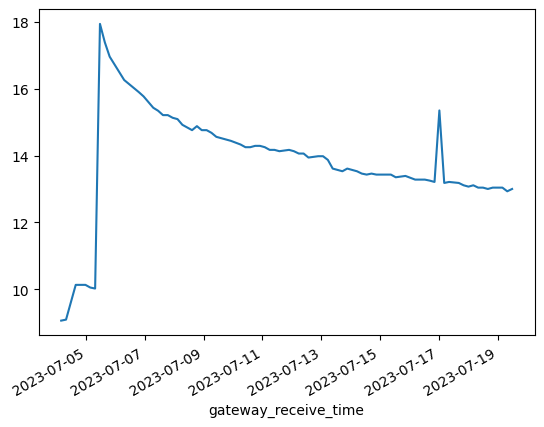

In [10]:
df_value = df[df['device_id'] == 418].set_index('gateway_receive_time')
df_value['value'].plot()

In [11]:
import pandas as pd
import requests

# Fetch the data from the URL
url = "https://langbrom.home.xs4all.nl/weer/archief/archiefdata.txt"
response = requests.get(url)
data = response.text

# Split the data into lines and remove the first seven lines
lines = data.split("\n")[7:]

# Extract the headers and rows
headers = ["Date", "Max Temp (C)", "Min Temp (C)", "Avg Temp (C)", "Rainfall (mm)", "Max Pressure (hPa)", "Min Pressure (hPa)"]
rows = [line.split(",") for line in lines if line.strip() != ""]

# Remove '\r' from the last column values
for row in rows:
    row[-1] = row[-1].rstrip('\r')

# Create a DataFrame using the extracted headers and rows
df_weer_leiden = pd.DataFrame(rows, columns=headers)
df_weer_leiden = df_weer_leiden[df_weer_leiden['Date'] != "1900-01-00"]
df_weer_leiden['Date'] = pd.to_datetime(df_weer_leiden['Date'] )
df_weer_leiden[df_weer_leiden.columns[1:]] = df_weer_leiden[df_weer_leiden.columns[1:]].astype(float)

# Display the DataFrame
df_weer_leiden = df_weer_leiden[df_weer_leiden['Date'] > datetime(2022,2,18)]
df_weer_leiden


,Date,Max Temp (C),Min Temp (C),Avg Temp (C),Rainfall (mm),Max Pressure (hPa),Min Pressure (hPa)
3923,2022-02-19,8.1,4.4,6.3,9.3,1013.4,1000.3
3924,2022-02-20,11.5,4.4,8.1,22.2,1010.9,988.8
3925,2022-02-21,8.3,5.4,7.0,1.8,1017.1,993.9
3926,2022-02-22,10.8,5.6,7.8,1.5,1021.0,1011.5
3927,2022-02-23,11.4,5.9,8.3,0.0,1025.1,1015.8
...,...,...,...,...,...,...,...
4424,2023-07-14,24.0,15.1,19.7,0.0,1017.9,1004.1
4425,2023-07-15,26.0,18.2,21.2,0.6,1006.9,1002.9
4426,2023-07-16,22.7,16.7,19.3,0.0,1015.0,1006.4
4427,2023-07-17,22.3,15.6,18.3,0.6,1021.4,1014.5


In [12]:
df_sensor_data = resampled_df.copy()
df_sensor_weer_data = df_sensor_data.merge(df_weer_leiden,how='left',left_on=['adjusted_gateway_receive_time'],right_on=['Date']).drop(columns=['adjusted_gateway_receive_time']).dropna()
df_sensor_weer_data

,located,min,max,mean,min_max_delta,Date,Max Temp (C),Min Temp (C),Avg Temp (C),Rainfall (mm),Max Pressure (hPa),Min Pressure (hPa)
0,Arendshorst,9.06,10.13,9.708000,1.07,2023-07-04,21.6,14.8,17.5,1.2,1013.2,1006.7
1,Arendshorst,10.02,17.94,14.472000,7.92,2023-07-05,18.8,11.5,15.0,34.5,1015.0,999.7
2,Arendshorst,15.77,16.26,15.976667,0.49,2023-07-06,22.6,13.6,17.8,0.0,1019.7,1014.5
3,Arendshorst,15.13,15.43,15.264000,0.30,2023-07-07,31.2,13.5,21.8,0.0,1020.3,1017.6
4,Arendshorst,14.76,15.09,14.875000,0.33,2023-07-08,34.3,17.6,24.9,0.0,1018.4,1015.4
...,...,...,...,...,...,...,...,...,...,...,...,...
1571,Zeemanlaan,3.49,3.63,3.578333,0.14,2023-07-14,24.0,15.1,19.7,0.0,1017.9,1004.1
1572,Zeemanlaan,3.58,3.71,3.635000,0.13,2023-07-15,26.0,18.2,21.2,0.6,1006.9,1002.9
1573,Zeemanlaan,3.55,3.63,3.581667,0.08,2023-07-16,22.7,16.7,19.3,0.0,1015.0,1006.4
1574,Zeemanlaan,3.49,3.60,3.571667,0.11,2023-07-17,22.3,15.6,18.3,0.6,1021.4,1014.5


In [13]:
sensor_dim_cols = ['located','device_name','located_datum','located_einddatum','located_diepte','leeftijd_plant', 'soort_plant','located_regio', 'extra_omschrijving']

df_sensor_info_org.columns = ['timestamp', 'device_name', 'located', 'omschrijving', 'foto_1','foto_2', 'located_diepte',
                          'lat_lon','located_datum_old','located_datum','located_tijd','located_einddatum','foto_3', 'foto_4', 
                          'leeftijd_plant', 'soort_plant','located_regio', 'extra_omschrijving']
df_dim_sensor = df_sensor_info_org[sensor_dim_cols].copy()
df_dim_sensor['old'] = pd.Series(np.where(df_dim_sensor['located'].str[-4:-1] == 'old','Yes','No'))

large_date = pd.to_datetime(pd.Timestamp.max.date())
df_dim_sensor['located_einddatum'] = df_dim_sensor['located_einddatum'].fillna(large_date)

df_dim_sensor.to_excel('./data/dim_sensor.xlsx', index=False, sheet_name='dim_sensor')

df_dim_sensor

,located,device_name,located_datum,located_einddatum,located_diepte,leeftijd_plant,soort_plant,located_regio,extra_omschrijving,old
0,Arendshorst,FF2 0-0193,2023-07-04,2262-04-11,30 cm,0-1 jaar,Jonge boom,Noord,"Nabij water, Nabij gebouwen",No
1,Veluwemeerlaan,FF2 0-0137,2023-07-04,2262-04-11,30 cm,Weet ik niet,Heesters,Noord,Open plek,No
2,Moskee Zwijgerlaan (old),FF2 0-0183,2023-06-06,2023-07-01,30 cm,0-1 jaar,Plantenvak,Noord,Geen,Yes
3,Langegracht Politie,FF2 0-0191,2023-07-04,2262-04-11,30 cm,1-2 jaar,Plant onder Boom,Midden,In berm,No
4,Molen Lammermarkt,FF2 0-0144,2023-07-04,2262-04-11,15 cm,Weet ik niet,Plantenvak,Midden,Geen,No
5,Haven binnenstad,FF2 0-0135,2023-07-04,2262-04-11,30 cm,0-1 jaar,Jonge boom,Midden,Nabij water,No
6,Beuk vismarkt,FF2 0-0180,2023-07-04,2262-04-11,30 cm,0-1 jaar,Jonge boom,Midden,Tussen bestrating,No
7,Nieuweroord,FF2 0-0179,2023-07-04,2262-04-11,30 cm,0-1 jaar,Jonge boom,West,Tussen gazon,No
8,Geesgrond West,FF2 0-0174,2023-07-04,2262-04-11,30 cm,Weet ik niet,Bosplantsoen,West,In park,No
9,Ketelmeer rotonde (2),FF2 0-0173,2023-07-04,2262-04-11,30 cm,Weet ik niet,Berm plantenvak,Noord,In berm,No


In [14]:
df_sensor_weer_data.to_excel('./data/time_series_analysis.xlsx', index=False, sheet_name='sensordata')

In [16]:
df_sensor_weer_data.columns

Index(['located', 'min', 'max', 'mean', 'min_max_delta', 'Date',
       'Max Temp (C)', 'Min Temp (C)', 'Avg Temp (C)', 'Rainfall (mm)',
       'Max Pressure (hPa)', 'Min Pressure (hPa)'],
      dtype='object')

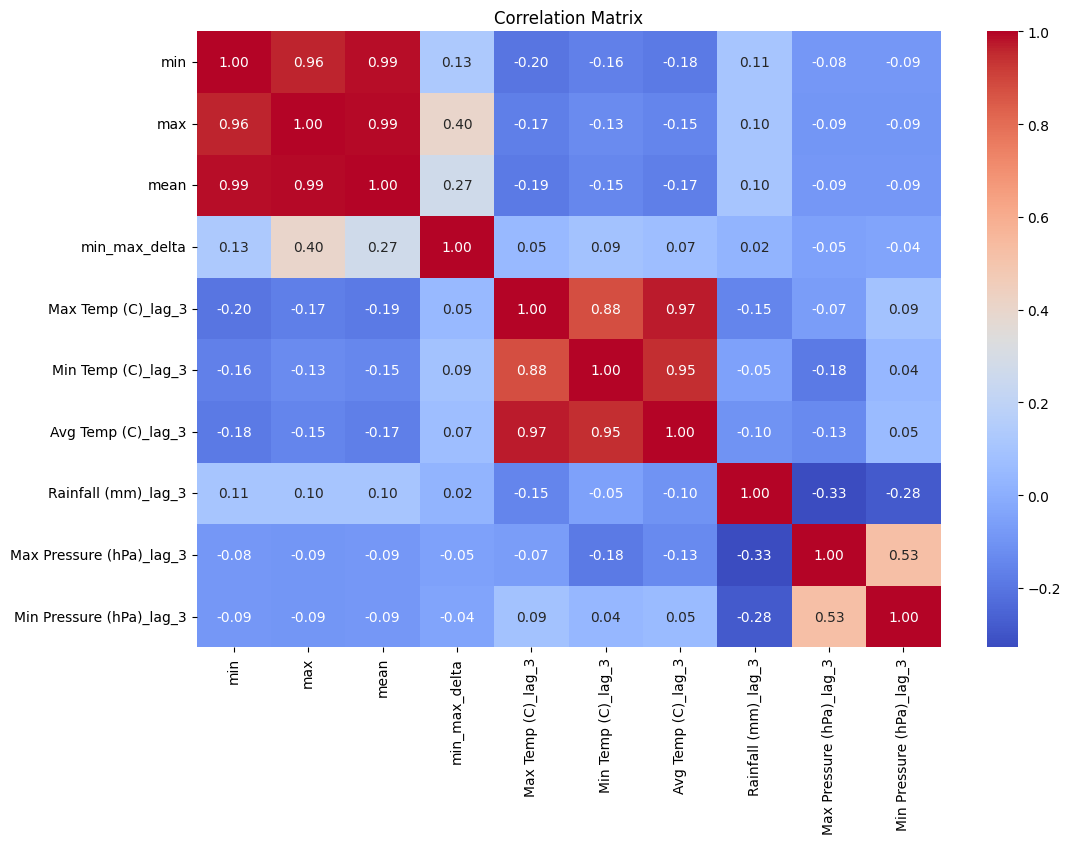

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have already imported the necessary libraries and loaded the dataframe 'df_sensor_weer_data'

# Create lag features for weather variables
lags = 3  # Number of lag features you want to create
weather_vars = ['Max Temp (C)', 'Min Temp (C)', 'Avg Temp (C)', 'Rainfall (mm)', 'Max Pressure (hPa)', 'Min Pressure (hPa)']

for var in weather_vars:
    for lag in range(1, lags + 1):
        df_sensor_weer_data[f'{var}_lag_{lag}'] = df_sensor_weer_data[var].shift(lag)

# Correlation Analysis
correlation_matrix = df_sensor_weer_data[['min', 'max', 'mean', 'min_max_delta'] + [f'{var}_lag_{lag}' for var in weather_vars]].corr()

# Data Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


C:\Users\JSpan\AppData\Local\Temp\ipykernel_8116\1598991287.py:10: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  'Max Pressure (hPa)', 'Min Pressure (hPa)']].corr()


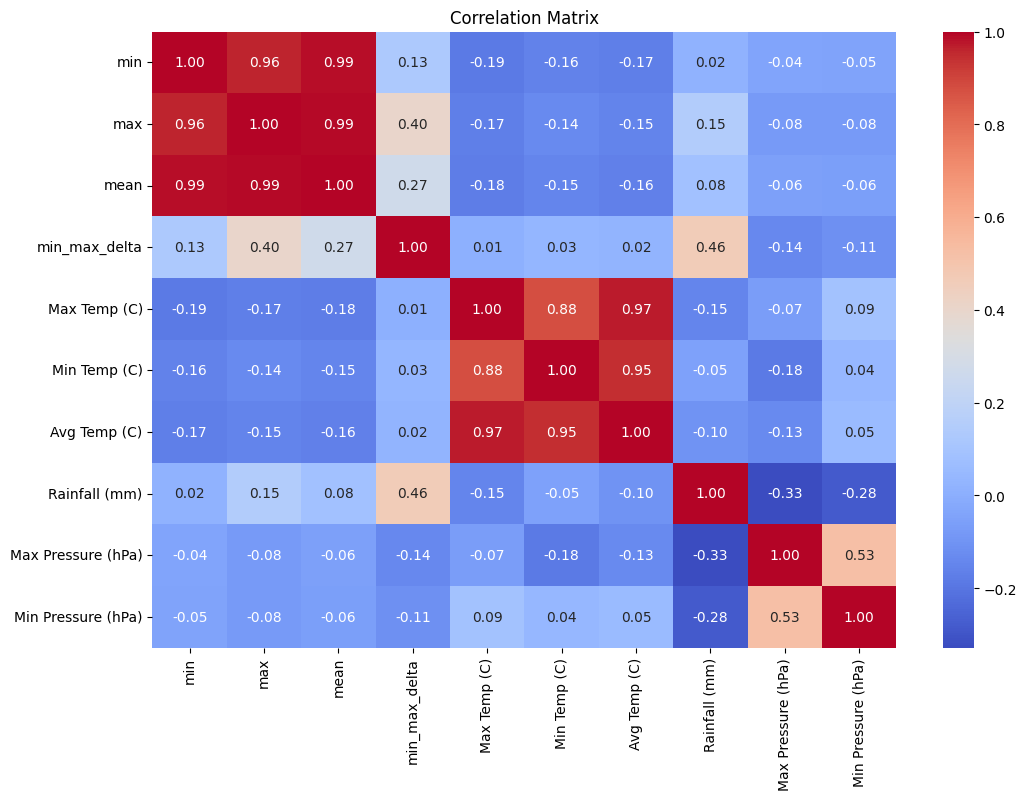

ValueError: If using all scalar values, you must pass an index

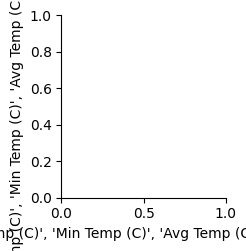

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have already imported the necessary libraries and loaded the dataframe 'df_sensor_weer_data'

# Correlation Analysis
correlation_matrix = df_sensor_weer_data[['min', 'max', 'mean', 'min_max_delta', 'Date',
       'Max Temp (C)', 'Min Temp (C)', 'Avg Temp (C)', 'Rainfall (mm)',
       'Max Pressure (hPa)', 'Min Pressure (hPa)']].corr()

# Data Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Scatter plots to visualize relationships between permittivity and weather variables
sns.pairplot(df_sensor_weer_data, vars=[['min', 'max', 'mean', 'min_max_delta', 'Date',
       'Max Temp (C)', 'Min Temp (C)', 'Avg Temp (C)', 'Rainfall (mm)',
       'Max Pressure (hPa)', 'Min Pressure (hPa)']], diag_kind='kde')
plt.show()

# Regression Analysis
from sklearn.linear_model import LinearRegression

# Choose the weather variable you want to use as the independent variable (e.g., Max Temp (C))
X = df_sensor_weer_data[['Max Temp (C)']]
# Choose the permittivity measure as the dependent variable (e.g., 'mean')
y = df_sensor_weer_data['mean']

# Fit the linear regression model
reg_model = LinearRegression()
reg_model.fit(X, y)

# Print the regression coefficients
print('Regression Coefficients:')
print('Intercept:', reg_model.intercept_)
print('Coefficient:', reg_model.coef_[0])

# Time Series Analysis
# Assuming 'Date' column is already in datetime format
df_sensor_weer_data.set_index('Date', inplace=True)

# Plot time series of permittivity measures and weather variables
df_sensor_weer_data[['min', 'max', 'mean']].plot(figsize=(12, 6))
plt.xlabel('Date')
plt.ylabel('Permittivity Measures')
plt.title('Permittivity Measures Over Time')
plt.show()

df_sensor_weer_data[['Max Temp (C)', 'Min Temp (C)', 'Avg Temp (C)', 'Rainfall (mm) Max', 'Pressure (hPa)', 'Min Pressure (hPa)']].plot(figsize=(12, 6))
plt.xlabel('Date')
plt.ylabel('Weather Variables')
plt.title('Weather Variables Over Time')
plt.show()
